
# Revenue, Orders and Product Demand Forecasting

## TL;DR

This notebook reviews the three-month Holt trend forecast and compares forecast
revenue, orders and product demand against management targets.


In [2]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

CURRENT_FOLDER = Path.cwd()

if CURRENT_FOLDER.name.lower() == "python":
    PROJECT_FOLDER = CURRENT_FOLDER.parent
else:
    PROJECT_FOLDER = CURRENT_FOLDER

FORECAST_REPORT = (
    PROJECT_FOLDER
    /"Supporting evidence"
    / "Forecasting_Analysis"
    / "Forecasting_Report.xlsx"
)

next_three_months = pd.read_excel(
    FORECAST_REPORT,
    sheet_name="Next_3_Months"
)

actual_forecast_target = pd.read_excel(
    FORECAST_REPORT,
    sheet_name="Actual_Forecast_Target"
)

product_demand = pd.read_excel(
    FORECAST_REPORT,
    sheet_name="Product_Demand_Summary"
)

next_three_months["Month"] = pd.to_datetime(
    next_three_months["Month"]
)

actual_forecast_target["Month"] = pd.to_datetime(
    actual_forecast_target["Month"]
)

next_three_months


,Month,Revenue_Forecast,Revenue_CI_Lower,Revenue_CI_Upper,Revenue_Target,Orders_Forecast,Orders_CI_Lower,Orders_CI_Upper,Order_Target,Demand_Forecast_Units,Demand_CI_Lower,Demand_CI_Upper,Units_Target,Revenue_Target_Achievement_Percentage,Order_Target_Achievement_Percentage,Demand_Target_Achievement_Percentage,Revenue_Target_Status,Order_Target_Status,Demand_Target_Status
0,2026-09-01,40970849.07,38987553.73,42954144.41,43636363.64,12338.79,11888.84,12788.74,87272.73,62657.94,59582.02,65733.86,65790.84,93.89,14.14,95.24,At Risk,Unlikely to Achieve,At Risk
1,2026-10-01,41046028.73,38241225.56,43850831.90,41818181.82,12349.34,11713.01,12985.66,83636.36,62766.18,58416.18,67116.18,65904.49,98.15,14.77,95.24,At Risk,Unlikely to Achieve,At Risk
2,2026-11-01,41120832.49,37685664.19,44556000.79,40000000.00,12359.83,11580.50,13139.17,80000.00,62873.87,57546.23,68201.52,66017.57,102.80,15.45,95.24,Possible - Forecast Above Target,Unlikely to Achieve,At Risk


## Next Three-Month Forecast

In [3]:

forecast_columns = [
    "Month",
    "Revenue_Forecast",
    "Revenue_CI_Lower",
    "Revenue_CI_Upper",
    "Revenue_Target",
    "Revenue_Target_Achievement_Percentage",
    "Revenue_Target_Status",
    "Orders_Forecast",
    "Order_Target",
    "Demand_Forecast_Units"
]

next_three_months[
    forecast_columns
]


,Month,Revenue_Forecast,Revenue_CI_Lower,Revenue_CI_Upper,Revenue_Target,Revenue_Target_Achievement_Percentage,Revenue_Target_Status,Orders_Forecast,Order_Target,Demand_Forecast_Units
0,2026-09-01,40970849.07,38987553.73,42954144.41,43636363.64,93.89,At Risk,12338.79,87272.73,62657.94
1,2026-10-01,41046028.73,38241225.56,43850831.90,41818181.82,98.15,At Risk,12349.34,83636.36,62766.18
2,2026-11-01,41120832.49,37685664.19,44556000.79,40000000.00,102.80,Possible - Forecast Above Target,12359.83,80000.00,62873.87


## Actual vs Forecast vs Target

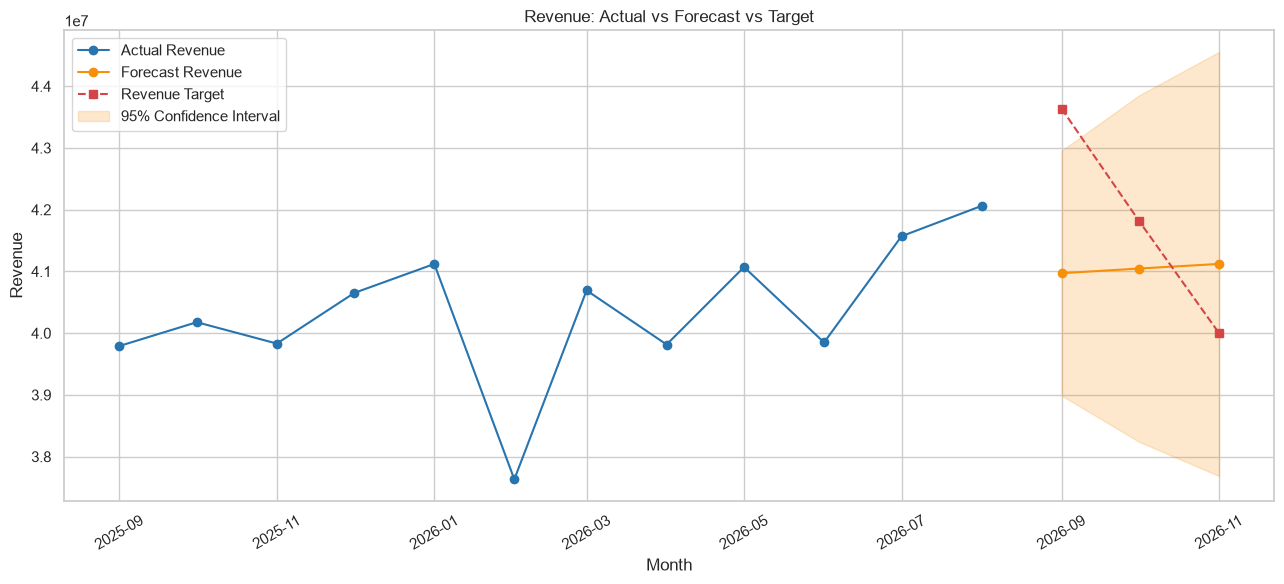

In [4]:

historical = actual_forecast_target[
    actual_forecast_target["Record_Type"]
    == "Actual"
].copy()

future = actual_forecast_target[
    actual_forecast_target["Record_Type"]
    == "Forecast"
].copy()

plt.figure(figsize=(13, 6))

plt.plot(
    historical["Month"],
    historical["Actual_Revenue"],
    marker="o",
    label="Actual Revenue",
    color="#2774AE"
)

plt.plot(
    future["Month"],
    future["Revenue_Forecast"],
    marker="o",
    label="Forecast Revenue",
    color="#F79009"
)

plt.plot(
    future["Month"],
    future["Revenue_Target"],
    marker="s",
    linestyle="--",
    label="Revenue Target",
    color="#D64545"
)

plt.fill_between(
    future["Month"],
    future["Revenue_CI_Lower"],
    future["Revenue_CI_Upper"],
    color="#F79009",
    alpha=0.20,
    label="95% Confidence Interval"
)

plt.title("Revenue: Actual vs Forecast vs Target")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Next-Quarter Target Assessment

In [5]:

quarter_revenue_forecast = next_three_months[
    "Revenue_Forecast"
].sum()

quarter_revenue_target = next_three_months[
    "Revenue_Target"
].sum()

quarter_orders_forecast = next_three_months[
    "Orders_Forecast"
].sum()

quarter_demand_forecast = next_three_months[
    "Demand_Forecast_Units"
].sum()

revenue_achievement = (
    quarter_revenue_forecast
    / quarter_revenue_target
    * 100
)

quarter_summary = pd.DataFrame(
    {
        "Metric": [
            "Revenue Forecast",
            "Revenue Target",
            "Revenue Target Achievement %",
            "Orders Forecast",
            "Product Demand Forecast"
        ],
        "Value": [
            quarter_revenue_forecast,
            quarter_revenue_target,
            revenue_achievement,
            quarter_orders_forecast,
            quarter_demand_forecast
        ]
    }
)

quarter_summary


,Metric,Value
0,Revenue Forecast,1.231377e+08
1,Revenue Target,1.254545e+08
2,Revenue Target Achievement %,9.815325e+01
3,Orders Forecast,3.704796e+04
4,Product Demand Forecast,1.882980e+05


## Top Forecasted Products

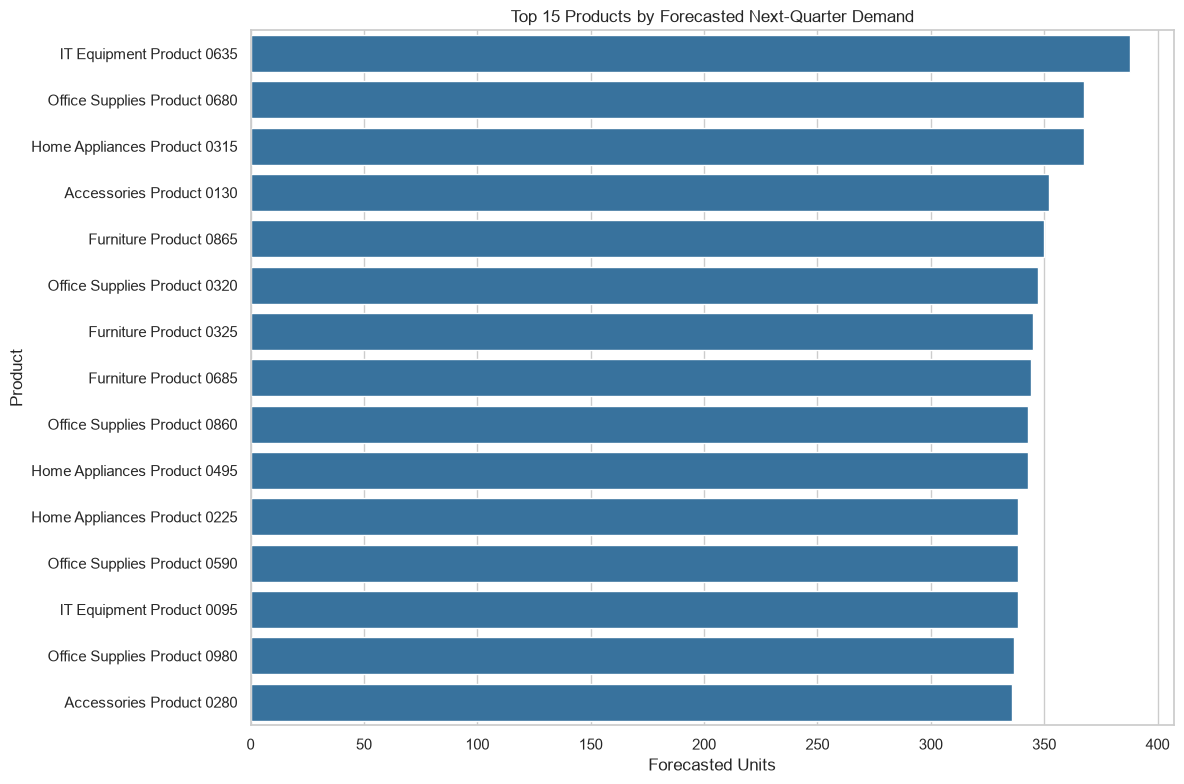

,Product_ID,Product_Name,Category,Next_Quarter_Demand,Average_Monthly_Forecast,Average_Demand_Trend_Percentage,Demand_Rank
0,P00635,IT Equipment Product 0635,IT Equipment,387.86,129.29,26.65,1
1,P00680,Office Supplies Product 0680,Office Supplies,367.65,122.55,17.65,2
2,P00315,Home Appliances Product 0315,Home Appliances,367.65,122.55,17.65,2
3,P00130,Accessories Product 0130,Accessories,352.09,117.36,13.12,3
4,P00865,Furniture Product 0865,Furniture,350.06,116.69,12.92,4
5,P00320,Office Supplies Product 0320,Office Supplies,347.11,115.70,11.08,5
6,P00325,Furniture Product 0325,Furniture,345.14,115.05,13.16,6
7,P00685,Furniture Product 0685,Furniture,344.40,114.80,10.65,7
8,P00860,Office Supplies Product 0860,Office Supplies,342.92,114.31,9.73,8
9,P00495,Home Appliances Product 0495,Home Appliances,342.92,114.31,9.73,8


In [6]:

top_products = product_demand.sort_values(
    "Next_Quarter_Demand",
    ascending=False
).head(15)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_products,
    y="Product_Name",
    x="Next_Quarter_Demand",
    color="#2774AE"
)

plt.title(
    "Top 15 Products by Forecasted Next-Quarter Demand"
)

plt.xlabel("Forecasted Units")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

top_products



## Key Assumptions and Limitations

- Only 12 months of historical data is available.
- The model uses a damped Holt trend and cannot fully validate annual seasonality.
- No major pricing, supply-chain or economic disruption is assumed.
- Future targets are extrapolated when explicit future targets are unavailable.
- Forecast confidence intervals reflect historical residual error.

## Takeaways

- Next-quarter revenue forecast is approximately ₹12.31 crore.
- Revenue target is approximately ₹12.55 crore.
- Expected achievement is approximately 98.15%, so the target is at risk.
- Forecasted next-quarter demand is approximately 188,298 units.
